### Import Libraries


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from datasets import load_dataset

### Load the dataset

In [2]:
emotion_dataset = load_dataset('dair-ai/emotion')

train_text = emotion_dataset['train']['text']
train_label = emotion_dataset['train']['label']

test_text = emotion_dataset['test']['text']
test_label = emotion_dataset['test']['label']


README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  129kB            

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [3]:
label_names = emotion_dataset['train'].features['label'].names

In [4]:
df_train = pd.DataFrame({
    'text': train_text,
    'label': [label_names[i] for i in train_label]
})

df_test = pd.DataFrame({
    'text': test_text,
    'label': [label_names[i] for i in test_label]
})

In [5]:
df_train.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [6]:
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [7]:
df_train.isnull().sum()

,0
text,0
label,0


### Exploratory Data Analysis ( EDA )

<Axes: xlabel='label', ylabel='count'>

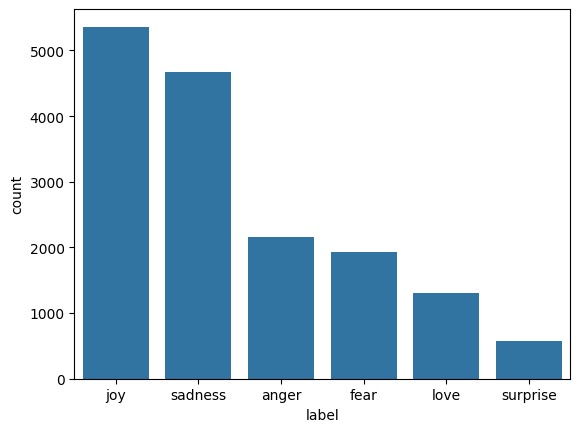

In [8]:
sns.countplot(x='label', data=df_train, order=df_train['label'].value_counts().index)

### Data Preprocessing - Using NLP

In [9]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000

tokenizer = Tokenizer(num_words=max_words, oov_token='<unk>')
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequence = tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence = pad_sequences(train_sequence, maxlen=50, padding='post', truncating='post')
padded_test_sequence = pad_sequences(test_sequence, maxlen=50, padding='post', truncating='post')

train_labels = np.array(train_label)
test_labels = np.array(test_label)

num_classes = len(np.unique(train_labels))
num_classes

print(f"Vocabulary size: {len(tokenizer.word_index)}")
print(f"Max Sentence length: {padded_train_sequence.shape[1]}")

Vocabulary size: 15213
Max Sentence length: 50


In [10]:
padded_train_sequence

array([[   2,  139,    3, ...,    0,    0,    0],
       [   2,   40,  101, ...,    0,    0,    0],
       [  17, 3060,    7, ...,    0,    0,    0],
       ...,
       [   2,    3,  327, ...,    0,    0,    0],
       [   2,    3,   14, ...,    0,    0,    0],
       [   2,   47,    7, ...,    0,    0,    0]], dtype=int32)

### Shared tuning Utilities

In [11]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight= 'balanced',
    classes = np.unique(train_labels),
    y           = train_labels
)
class_weight_dict = dict(enumerate(class_weights))

##### Early stopping

In [12]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

### Foundation Models - RNN, LSTM, GRU



#### RNN

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Embedding, Dense, Dropout


rnn_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 120, input_length = 50),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units= num_classes, activation='softmax') #output
])


rnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [14]:
rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data = (padded_test_sequence, test_labels),
    epochs=20,
    batch_size=32,
    class_weight= class_weight_dict,
    callbacks=[early_stopping]
)

rnn_loss, rnn_accuraccy = rnn_model.evaluate(padded_test_sequence, test_labels)
print(f"rnn loss:  {rnn_loss}")
print(f"rnn accuracy: {rnn_accuraccy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 46ms/step - accuracy: 0.1575 - loss: 1.9038 - val_accuracy: 0.1375 - val_loss: 1.7954
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 39s 43ms/step - accuracy: 0.1621 - loss: 1.8013 - val_accuracy: 0.0865 - val_loss: 1.8122
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.1599 - loss: 1.7861 - val_accuracy: 0.1960 - val_loss: 1.7776
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 45s 52ms/step - accuracy: 0.1598 - loss: 1.7726 - val_accuracy: 0.1200 - val_loss: 1.7953
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.1520 - loss: 1.8120 - val_accuracy: 0.1365 - val_loss: 1.7844
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 42ms/step - accuracy: 0.1349 - loss: 1.8351 - val_accuracy: 0.0815 - val_loss: 1.8172
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1960 - loss: 1.7776
rnn loss:  1.777630090713501
rnn accuracy: 0.19599999487400055


#### LSTM

In [15]:
lstm_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 120, input_length = 50),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units= num_classes, activation='softmax') #output
])


lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data = (padded_test_sequence, test_labels),
    epochs=20,
    batch_size=32,
    class_weight= class_weight_dict,
    callbacks=[early_stopping]
)

lstm_loss, lstm_accuraccy = lstm_model.evaluate(padded_test_sequence, test_labels)
print(f"LSTM loss:  {lstm_loss}")
print(f"LSTM accuracy: {lstm_accuraccy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 62s 114ms/step - accuracy: 0.1531 - loss: 1.7954 - val_accuracy: 0.0700 - val_loss: 1.7924
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 83s 117ms/step - accuracy: 0.1694 - loss: 1.7940 - val_accuracy: 0.0350 - val_loss: 1.7870
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 81s 114ms/step - accuracy: 0.1762 - loss: 1.7920 - val_accuracy: 0.3410 - val_loss: 1.7763
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 58s 116ms/step - accuracy: 0.2164 - loss: 1.7660 - val_accuracy: 0.2870 - val_loss: 1.6904
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 58s 116ms/step - accuracy: 0.3732 - loss: 1.5179 - val_accuracy: 0.5275 - val_loss: 1.2959
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 59s 117ms/step - accuracy: 0.6531 - loss: 1.0273 - val_accuracy: 0.8085 - val_loss: 0.6529
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 81s 116ms/step - accuracy: 0.8282 - loss: 0.6035 - val_accuracy: 0.8560 - val_loss: 0.5128
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 59s 118ms/step - accuracy: 0.8889 - loss: 0

#### GRU

In [16]:

gru_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 120, input_length = 50),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units= num_classes, activation='softmax') #output
])


gru_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data = (padded_test_sequence, test_labels),
    epochs=20,
    batch_size=32,
    class_weight= class_weight_dict,
    callbacks=[early_stopping]
)

gru_loss, gru_accuraccy = gru_model.evaluate(padded_test_sequence, test_labels)
print(f"GRU loss:  {gru_loss}")
print(f"GRU accuracy: {gru_accuraccy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 54s 100ms/step - accuracy: 0.1319 - loss: 1.7959 - val_accuracy: 0.3460 - val_loss: 1.7749
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 51s 101ms/step - accuracy: 0.1542 - loss: 1.7953 - val_accuracy: 0.2890 - val_loss: 1.7828
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 49s 99ms/step - accuracy: 0.1448 - loss: 1.7939 - val_accuracy: 0.0400 - val_loss: 1.8056
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.3460 - loss: 1.7749
GRU loss:  1.7748857736587524
GRU accuracy: 0.34599998593330383


### Ranking and Selection

In [ ]:
result_df = pd.DataFrame({
    'Model': ["RNN", "LSTM", "GRU"],
    'Test loss': [rnn_loss, lstm_loss, gru_loss],
    'Test accuracy': [rnn_accuraccy, lstm_accuraccy, gru_accuraccy]
}).sort_values(by='Test accuracy', ascending=False)
result_df

## Advanced Bidirectional GRU

In [18]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim = max_words, output_dim = 300, input_length = 50),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') #output
])

BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

BiGRU.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data = (padded_test_sequence, test_labels),
    epochs=20,
    batch_size=32,
    class_weight= class_weight_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 145s 279ms/step - accuracy: 0.5717 - loss: 1.0299 - val_accuracy: 0.8575 - val_loss: 0.5014
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 279ms/step - accuracy: 0.9162 - loss: 0.2268 - val_accuracy: 0.9135 - val_loss: 0.2110
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 141s 277ms/step - accuracy: 0.9449 - loss: 0.1468 - val_accuracy: 0.9170 - val_loss: 0.2298
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 277ms/step - accuracy: 0.9632 - loss: 0.1010 - val_accuracy: 0.9175 - val_loss: 0.2848
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 137s 274ms/step - accuracy: 0.9721 - loss: 0.0738 - val_accuracy: 0.9125 - val_loss: 0.3029


In [20]:
Bigru_loss, Bigru_accuraccy = BiGRU.evaluate(padded_test_sequence, test_labels)
print(f"BiGRU loss:  {Bigru_loss}")
print(f"BiGRU accuracy: {Bigru_accuraccy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - accuracy: 0.9135 - loss: 0.2110
BiGRU loss:  0.21100695431232452
BiGRU accuracy: 0.9135000109672546


### Final Model Confusion Matrices

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step


<Axes: >

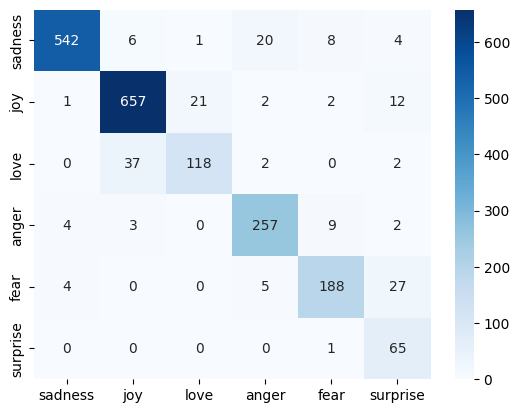

In [21]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequence), axis=1)

sns.heatmap(confusion_matrix(test_label, BiGRU_predictions), annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)

### Final Predictions

In [22]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip last minute.",
    "I feel terrified when walking alone.",
    "I was shocked by the unexpected gift!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)

for i in range(len(sample_texts)):
  print(f"Text: {sample_texts[i]}\n Predicted_emotion: {label_names[sample_predictions[i]]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Text: I can't believe how happy I am right now, this is amazing!
 Predicted_emotion: surprise
Text: I feel so alone and hopeless today.
 Predicted_emotion: sadness
Text: I am furious that they cancelled the trip last minute.
 Predicted_emotion: anger
Text: I feel terrified when walking alone.
 Predicted_emotion: fear
Text: I was shocked by the unexpected gift!
 Predicted_emotion: surprise


### Save Model & Tokenizer

In [26]:
import os
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True)

# Save the model
BiGRU.save(os.path.join(model_dir, 'BiGRU_Model.keras'))

# Save the tokenizer
with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
  pickle.dump(tokenizer, file)